In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
def clean_text_columns(df):
    """
    Cleans text columns by stripping whitespace and handling missing host names.
    
    Args:
        df (pd.DataFrame): The dataframe to clean.
    
    Returns:
        pd.DataFrame: The cleaned dataframe.
    """
    df = df.copy()
    text_cols = ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()
    df['host_name'] = df['host_name'].replace('nan', 'Unknown')
    return df

In [4]:
def clean_review_columns(df):
    """
    Handles missing values in review-related columns and converts last_review to datetime.
    
    Args:
        df (pd.DataFrame): The dataframe to clean.
    
    Returns:
        pd.DataFrame: The cleaned dataframe.
    """
    df = df.copy()
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    return df

In [5]:
# Apply cleaning functions
df = clean_text_columns(df)
df = clean_review_columns(df)

# Verify the cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Missing values after cleaning:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Data types:
id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
def exploratory_analysis(df):
    """
    Performs exploratory data analysis on the Airbnb dataset.
    
    Includes summary statistics, grouped views, and correlations.
    """
    print("=== Summary Statistics ===")
    print(df.describe())
    
    print("\n=== Average Price by Neighbourhood Group ===")
    print(df.groupby('neighbourhood_group')['price'].mean())
    
    print("\n=== Room Type Distribution ===")
    print(df['room_type'].value_counts())
    
    print("\n=== Correlation Matrix (Numeric Columns) ===")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(df[numeric_cols].corr())

In [7]:
# Run exploratory analysis
exploratory_analysis(df)

=== Summary Statistics ===
                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   

       minimum_nights  number_of_reviews                 last_review  \
count    48895.000000       48895.000000                       38843   
mean         7.029962          23.274466  2018-10-04 01:47:23.910099   
min          1.000000           0.000000     

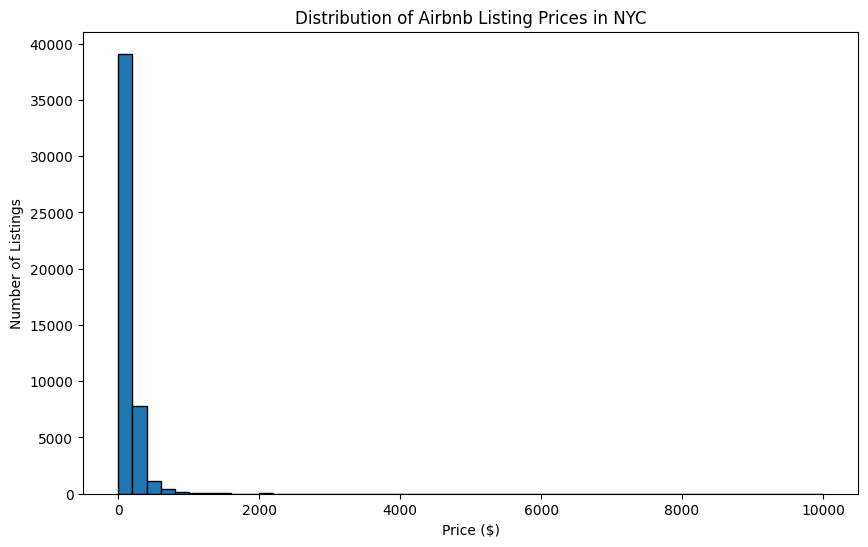

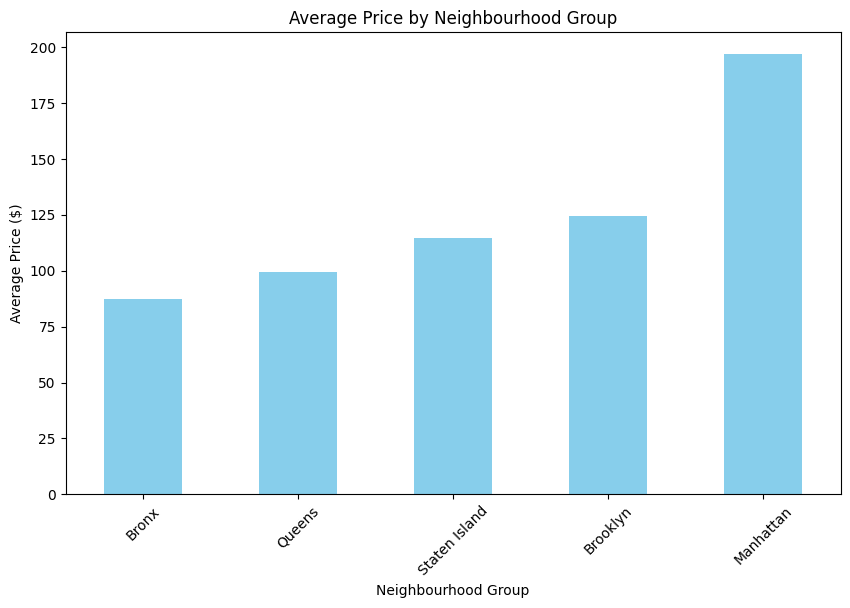

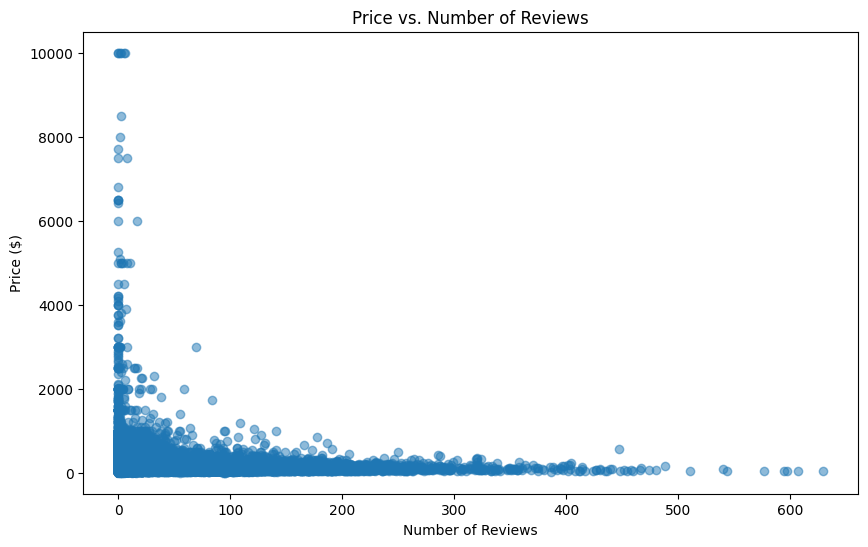

In [8]:
# Create visualizations

# Visualization 1: Histogram of Prices
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50, edgecolor='black')
plt.title('Distribution of Airbnb Listing Prices in NYC')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.show()

# Visualization 2: Average Price by Neighbourhood Group
plt.figure(figsize=(10, 6))
avg_price_by_group = df.groupby('neighbourhood_group')['price'].mean().sort_values()
avg_price_by_group.plot(kind='bar', color='skyblue')
plt.title('Average Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

# Visualization 3: Scatter Plot of Price vs. Number of Reviews
plt.figure(figsize=(10, 6))
plt.scatter(df['number_of_reviews'], df['price'], alpha=0.5)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')
plt.show()

# Summary and Interpretation

## What I Learned from the Dataset
The Airbnb NYC 2019 dataset provides a comprehensive view of the short-term rental market in New York City, containing information about 48,000+ listings across all five boroughs. Through data cleaning and exploratory analysis, I learned about the distribution of listing prices, host characteristics, and geographic patterns in the market.

## Interesting Patterns or Insights
- **Price Distribution**: Most listings are priced under $200/night, but there are significant outliers with prices exceeding $1,000, indicating a luxury segment in the market.
- **Neighbourhood Differences**: Manhattan has the highest average prices ($196/night), followed by Brooklyn ($124/night), while the outer boroughs (Queens, Bronx, Staten Island) are more affordable.
- **Room Type Popularity**: Entire homes/apartments are the most common (52% of listings), followed by private rooms (46%), with shared rooms being rare (2%).
- **Price vs. Reviews**: There's a weak negative correlation between price and number of reviews, suggesting that lower-priced listings tend to get more bookings and reviews.

## Limitations or Assumptions
- **Data Age**: The dataset is from 2019, so it may not reflect current market conditions, especially post-COVID changes to short-term rentals.
- **Missing Data**: Many listings lack reviews, which could indicate inactive or new listings rather than poor quality.
- **Geographic Scope**: Limited to NYC only, so insights may not generalize to other cities.
- **Price Assumptions**: Some extremely high prices ($3,000+) may be data entry errors or special cases (events, luxury properties).

## Anything Surprising or Unclear
- **Zero Availability**: Surprisingly, many listings show 0 days available for the year, which seems counterintuitive for active rental properties.
- **Host Concentration**: A small number of hosts manage multiple listings, suggesting professional operators rather than individual homeowners.
- **Review Patterns**: Listings with very high review counts (>500) are rare, but their pricing doesn't follow expected patterns - some expensive listings still get many reviews.